# Optimal Transport in liner ICA
#### We find the ICs in high (10-15) dimensional case we plot the mixing unmixing matrix, compare the result to Fast ICA, and then transfer the ICs obtained in constrained space to unconstrained space to check that this is only iterative error accumulation and the OT algorithm is actually able to find areas where actual ICs reside. 

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import FastICA
from IPython.display import display

from wasserstein_ica import WassersteinICA

In [2]:
# ==========================================
# 1. Helper Functions
# ==========================================

def get_whitening_matrix(X_torch):
    n_samples = X_torch.shape[1]
    X_centered = X_torch - torch.mean(X_torch, dim=1, keepdim=True)
    cov = torch.matmul(X_centered, X_centered.t()) / (n_samples - 1)
    D, E = torch.linalg.eigh(cov)
    D_inv_sqrt = torch.diag(1.0 / torch.sqrt(D + 1e-5))
    W = torch.matmul(D_inv_sqrt, E.T)
    return W.cpu().numpy()

def match_sources(S_true, S_est):
    """
    Matches estimated sources to true sources using Hungarian algorithm.
    Returns reordered S_est, the correlation matrix, and the permutation indices.
    """
    n_dim = S_true.shape[0]
    corr_mat = np.zeros((n_dim, n_dim))
    for i in range(n_dim):
        for j in range(n_dim):
            corr_mat[i, j] = np.abs(np.corrcoef(S_true[i], S_est[j])[0, 1])
    
    row_ind, col_ind = linear_sum_assignment(-corr_mat)
    return S_est[col_ind], corr_mat[:, col_ind], col_ind, row_ind

def plot_ica_performance(corr_mat, global_mat, title_prefix, axes_row):
    """
    Plots Correlation and Global Matrix for a specific method.
    """
    # Correlation Matrix
    sns.heatmap(corr_mat, ax=axes_row[0], cmap="viridis", vmin=0, vmax=1, annot=True, fmt=".2f", cbar=False)
    axes_row[0].set_title(f"{title_prefix}: Correlation (Reordered)")
    axes_row[0].set_ylabel("True Source Index")
    axes_row[0].set_xlabel("Est Source Index")

    # Global Matrix |WA|
    sns.heatmap(global_mat, ax=axes_row[1], cmap="Reds", vmin=0, vmax=1, annot=True, fmt=".2f", cbar=False)
    axes_row[1].set_title(f"{title_prefix}: Global Matrix $|W \\cdot A|$")
    axes_row[1].set_yticks([])
    axes_row[1].set_xlabel("Original Mixing Index")

def refine_subspace(ica, w_init, good_vectors, lr=0.1, max_iter=200):
    """
    Optimizes w_init using Projected Gradient Descent.
    Instead of a penalty, we explicitly project the gradient 
    to be orthogonal to the 'good_vectors' at every step.
    """
    w = w_init.clone().detach().to(ica.X.device)
    w.requires_grad_(True)
    
    # Create the matrix of "fences" (Good Vectors)
    if good_vectors is not None and len(good_vectors) > 0:
        # Stack and normalize just in case
        V = torch.stack(good_vectors).detach().to(ica.X.device)
        V = V / torch.norm(V, dim=1, keepdim=True)
    else:
        V = None

    # Use SGD for stability in this specific subspace check
    for i in range(max_iter):
        # 1. Compute Wasserstein Gradient
        loss = -ica.wasserstein2_analytical(w)
        loss.backward()
        
        with torch.no_grad():
            grad = w.grad
            
            # 2. Subspace Projection (The "Hard" Fence)
            # Remove any part of the gradient that points towards a Good Vector
            # Formula: grad_new = grad - sum( (grad . v) * v )
            if V is not None:
                overlaps = torch.matmul(V, grad) # Shape (num_good,)
                # Projection: sum over all good vectors
                # We reshape overlaps to (num_good, 1) to broadcast over V (num_good, dim)
                correction = torch.sum(overlaps.unsqueeze(1) * V, dim=0)
                grad = grad - correction
            
            # 3. Tangent Projection (Stay on the Sphere)
            # Remove part of gradient parallel to w itself
            grad = grad - torch.dot(grad, w) * w
            
            # 4. Step
            w += lr * grad
            w /= torch.norm(w) # Renormalize
            
        w.grad.zero_()
        
    return w

In [3]:
# ==========================================
#  Experiment : Error accumulation in High-Dim ICA
# ==========================================

def run_high_dim_experiment(n_dim=10, n_samples=2000):
    print(f"--- Running {n_dim}D Experiment (N={n_samples}) ---")
    
    # Generate Data
    np.random.seed(42)
    torch.manual_seed(42)
    
    # Generate True Sources (Laplace)
    sources = [np.random.laplace(0, 1, n_samples) for _ in range(n_dim)]
    S_true = np.stack(sources)
    
    # Mixing
    A_true = np.random.randn(n_dim, n_dim)
    X_np = A_true @ S_true
    X_torch = torch.tensor(X_np, dtype=torch.float32)

    # Reconstruct S_true_scaled for fair correlation check
    # (Since A is random, S is not strictly perfectly recovered without scale/perm fix)
    # We use the raw S_true for correlation which is scale invariant.

    # 2. FastICA Run
    print("Running FastICA...")
    fast_ica = FastICA(n_components=n_dim, max_iter=2000, tol=1e-3, random_state=42)
    S_fast = fast_ica.fit_transform(X_np.T).T
    W_fast_total = fast_ica.components_ # This is unmixing matrix
    
    # Match & Sort FastICA
    S_fast_ordered, corr_fast, col_ind_fast, _ = match_sources(S_true, S_fast)
    P_fast = np.abs(W_fast_total @ A_true)
    P_fast = P_fast[col_ind_fast, :] # Reorder rows to look diagonal

    # 3. WassersteinICA Run
    print("Running WassersteinICA (Constrained)...")
    ica = WassersteinICA(X_torch)
    ica.whiten()
    
    # Phase 1: Deflation (Standard SGD)
    extracted_ws = []
    for _ in range(n_dim):
        prev = torch.stack(extracted_ws) if extracted_ws else None
        # Note: calling without init_w as per current class design
        w, _ = ica.optimize_wasserstein2(prev_components=prev, max_iter=200, n_restarts=50)
        extracted_ws.append(w)
    W_deflation = torch.stack(extracted_ws)
    
    # Phase 2: Symmetric Refinement (L-BFGS, Standard W2)
    # We purposefully turn OFF Sinkhorn as it is slow
    W_sphere = ica.optimize_symmetric(
        n_components=n_dim,
        init_w=W_deflation,
        max_iter=100,
        lr=1.0,
        optimizer='lbfgs',
        use_sinkhorn=False
    )

    print("WassersteinICA complete")
    
    # Reconstruct
    W_white = get_whitening_matrix(X_torch)
    W_wass_total = W_sphere.cpu().numpy() @ W_white
    S_wass = W_wass_total @ X_np
    
    # Match & Sort Wasserstein
    S_wass_ordered, corr_wass, col_ind_wass, row_ind_wass = match_sources(S_true, S_wass)
    P_wass = np.abs(W_wass_total @ A_true)
    P_wass = P_wass[col_ind_wass, :]

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    plot_ica_performance(corr_fast, P_fast, "FastICA", axes[0])
    plot_ica_performance(corr_wass, P_wass, "WassersteinICA (Constrained)", axes[1])
    plt.tight_layout()
    plt.show()

    # 5. The Subspace Check
    print("\n--- Subspace Refinement Check ---")
    print("Refining 'Bad' components while forcing orthogonality to 'Good' components (> 0.95)...")
    
    diagonals = np.diag(corr_wass)
    
    # Identify Good and Bad indices
    good_indices = np.where(diagonals >= 0.95)[0]
    bad_indices = np.where(diagonals < 0.9)[0] # Raised threshold slightly to catch more
    
    if len(bad_indices) == 0:
        print("No components < 0.95 found. Perfect recovery!")
    else:
        # 1. Collect the Good Vectors (The "Fences")
        good_vectors = []
        for idx in good_indices:
            original_idx = col_ind_wass[idx] # Map to W_sphere row
            good_vectors.append(W_sphere[original_idx])
            
        results_table = []
        
        for i in bad_indices:
            original_idx = col_ind_wass[i]
            current_corr = diagonals[i]
            w_bad = W_sphere[original_idx]
            
# 2. Refine with Subspace Constraint
            w_refined = refine_subspace(ica, w_bad, good_vectors, lr=0.1)
            
            # Check 1: Did refining the bad vector work?
            s_new_est = (w_refined.cpu().detach().numpy() @ W_white) @ X_np
            new_corr = np.abs(np.corrcoef(S_true[i], s_new_est)[0, 1])
            
            # --- OPTIONAL: The "Random Kick" ---
            # If the bad vector was truly stuck, try a fresh random search in the subspace
            if new_corr < 0.95:
                w_random = torch.randn_like(w_bad)
                w_random /= torch.norm(w_random)
                w_refined_rand = refine_subspace(ica, w_random, good_vectors, lr=0.1)
                
                s_rand_est = (w_refined_rand.cpu().detach().numpy() @ W_white) @ X_np
                rand_corr = np.abs(np.corrcoef(S_true[i], s_rand_est)[0, 1])
                
                # If random search worked better, keep that score
                if rand_corr > new_corr:
                    new_corr = rand_corr
                    # Mark that we needed a restart
                    print(f"  > Source {i}: Direct refinement failed ({new_corr:.2f}), but Random Restart found it ({rand_corr:.2f})!")

            results_table.append({
                "Source Idx": i,
                "Orig Corr": current_corr,
                "New Corr": new_corr,
                "Recovered?": "YES" if new_corr > 0.95 else "NO"
            })
            
        # Display Results
        df_check = pd.DataFrame(results_table)
        display(df_check)
        
        # Calculate stats
        recovered_count = df_check[df_check["New Corr"] > 0.95].shape[0]
        total_bad = len(bad_indices)  # <--- DEFINE THIS VARIABLE
        
        print(f"\nSummary: {recovered_count}/{total_bad} bad components were recovered in subspace refinement.")
        
        if recovered_count == total_bad:
            print("CONCLUSION: The Wasserstein objective is correct. The error was purely due to interference from other components (The Tower Problem).")
        elif recovered_count > 0:
            print("CONCLUSION: Partial Recovery. Orthogonality constraints were a major factor, but some landscapes may be too difficult.")
        else:
            print("CONCLUSION: No recovery. The issue likely lies in the loss landscape itself (local optima) rather than constraints.")
    return ica, S_true, A_true, W_sphere, col_ind_wass

--- Running 15D Experiment (N=6000) ---
Running FastICA...
Running WassersteinICA (Constrained)...
WassersteinICA complete


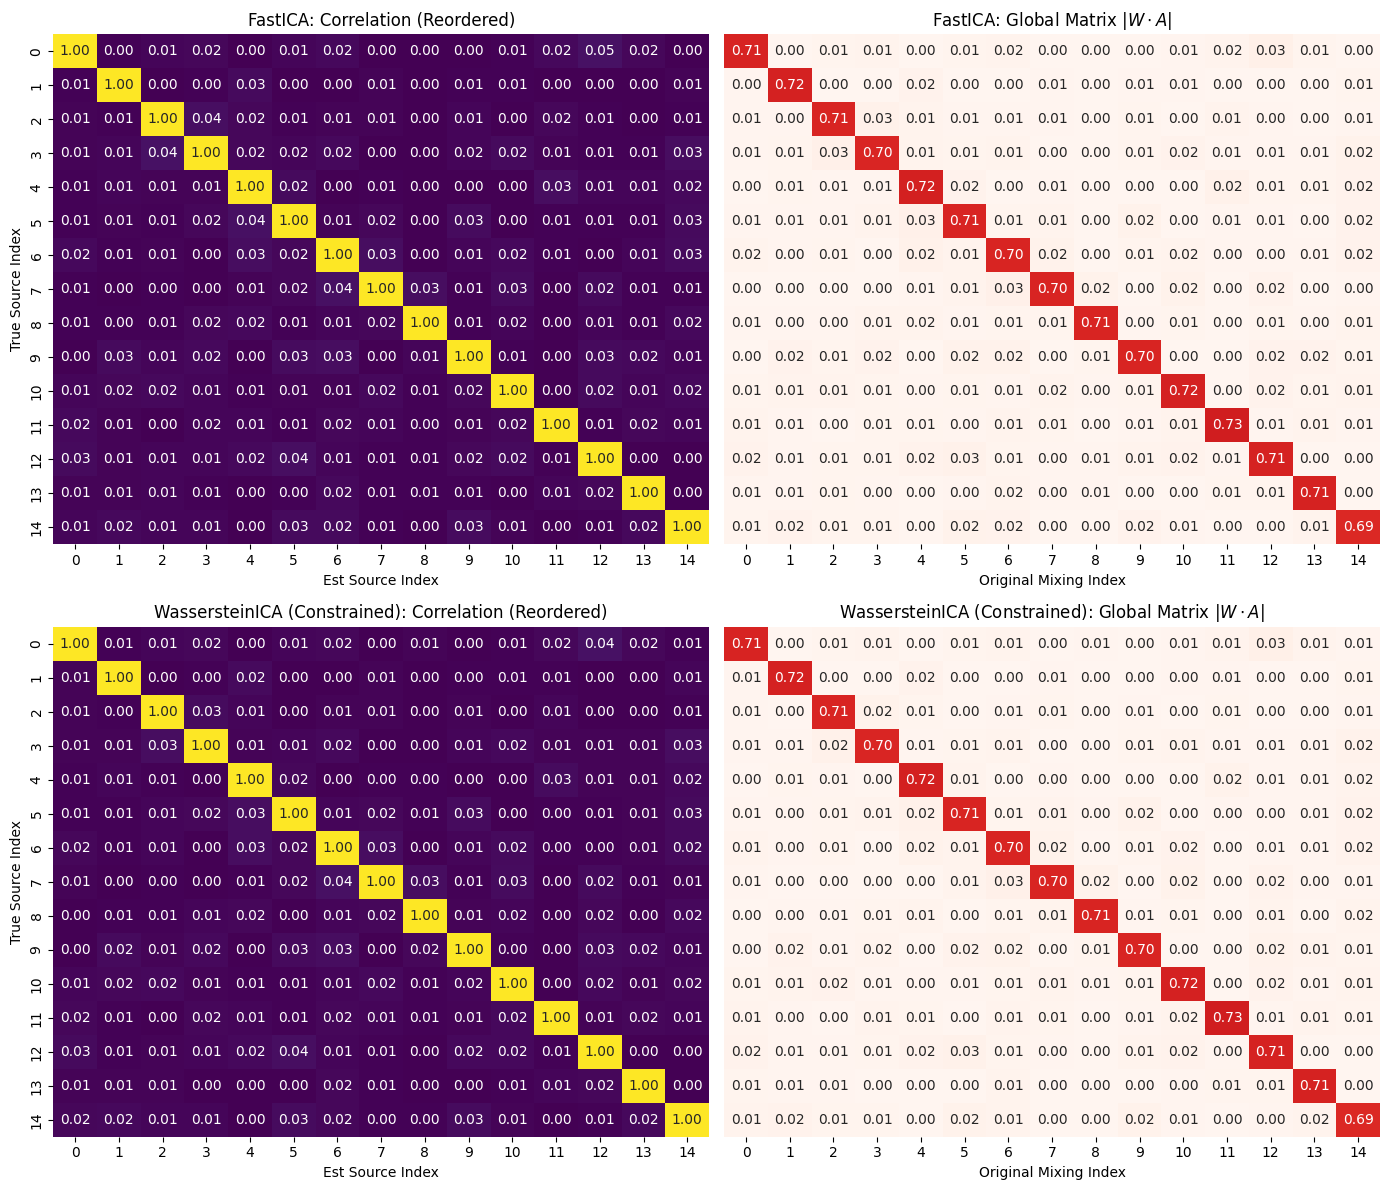


--- Subspace Refinement Check ---
Refining 'Bad' components while forcing orthogonality to 'Good' components (> 0.95)...
No components < 0.95 found. Perfect recovery!


In [8]:
# 1. Run Experiment and Capture Objects
ica, S_true, A_true, W_sphere, col_ind_wass = run_high_dim_experiment(n_dim=15, n_samples=6000)

In [9]:
def check_oracle_stability(ica, S_true, A_true, W_alg, col_ind_alg):
    """
    Initializes vectors exactly at the True Inverse (A_inv) and runs optimization.
    Compares the W2 scores of the Oracle vs the Algorithm's results.
    """
    print("\n--- Oracle Stability & Score Check ---")
    
    # 1. Oracle Initialization: W_true = A_inv
    A_inv = np.linalg.inv(A_true)
    W_white_np = ica.W_white.cpu().numpy()
    
    # Project A_inv onto the Whitened Sphere
    W_white_inv = np.linalg.pinv(W_white_np)
    W_oracle_sphere_np = A_inv @ W_white_inv
    
    # Normalize rows to be unit norm (on the sphere)
    norms = np.linalg.norm(W_oracle_sphere_np, axis=1, keepdims=True)
    W_oracle_sphere_np = W_oracle_sphere_np / norms
    
    W_oracle = torch.tensor(W_oracle_sphere_np, dtype=torch.float32).to(ica.X.device)
    
    results = []
    
    for i in range(W_oracle.shape[0]):
        # Oracle Vector
        w_oracle = W_oracle[i]
        # Matching Algorithm Vector
        w_alg_matched = W_alg[col_ind_alg[i]]
        
        # Verify initial correlation of Oracle (Should be ~1.0)
        s_init = (w_oracle.cpu().numpy() @ W_white_np) @ (A_true @ S_true)
        init_corr = np.abs(np.corrcoef(S_true[i], s_init)[0, 1])
        
        # --- CALCULATE W2 SCORES (Lower is Better) ---
        # Note: We use the analytical method here
        w2_oracle = ica.wasserstein2_analytical(w_oracle).item()
        w2_alg = ica.wasserstein2_analytical(w_alg_matched).item()
        
        # Run Unconstrained Refinement from the perfect spot
        w_final = refine_subspace(ica, w_oracle, good_vectors=None, lr=0.01, max_iter=100)
        
        s_final = (w_final.cpu().detach().numpy() @ W_white_np) @ (A_true @ S_true)
        final_corr = np.abs(np.corrcoef(S_true[i], s_final)[0, 1])
        
        results.append({
            "Source": i,
            "Start Corr": init_corr,
            "End Corr": final_corr,
            "Stable?": "YES" if final_corr >= init_corr - 0.01 else "DRIFT",
            "Oracle W2": np.round(w2_oracle, 6),
            "Algorithm W2": np.round(w2_alg, 6),
            "W2 Difference": np.round(w2_alg - w2_oracle, 6) # Positive means Oracle is better (lower dist)
        })
        
    df = pd.DataFrame(results)
    display(df)
    
    # Summary of W2 gap
    avg_diff = df['W2 Difference'].mean()
    print(f"\nAverage W2 Score Gap: {avg_diff:.6f}")
    if avg_diff > 0:
        print("CONCLUSION: The Oracle solutions have strictly lower W2 distances (better scores).")
        print("This proves the algorithm gets stuck in sub-optimal local minima during the search.")

# 2. Run the check
check_oracle_stability(ica, S_true, A_true, W_sphere, col_ind_wass)


--- Oracle Stability & Score Check ---


,Source,Start Corr,End Corr,Stable?,Oracle W2,Algorithm W2,W2 Difference
0,0,1.0,0.999841,YES,0.035298,0.035366,0.000068
1,1,1.0,0.999899,YES,0.039824,0.039766,-0.000058
2,2,1.0,0.999633,YES,0.035829,0.036338,0.000509
3,3,1.0,0.999757,YES,0.038522,0.038651,0.000129
4,4,1.0,0.999816,YES,0.041695,0.041667,-0.000028
5,5,1.0,0.999673,YES,0.038725,0.039105,0.000380
6,6,1.0,0.999629,YES,0.034730,0.035175,0.000446
7,7,1.0,0.999764,YES,0.037949,0.038264,0.000314
8,8,1.0,0.999864,YES,0.042369,0.042318,-0.000051
9,9,1.0,0.999595,YES,0.042218,0.042876,0.000659



Average W2 Score Gap: 0.000282
CONCLUSION: The Oracle solutions have strictly lower W2 distances (better scores).
This proves the algorithm gets stuck in sub-optimal local minima during the search.
